# 03 — Experiments: feature extractors × classifiers

Compares OCR configurations on a fixed synthetic split and on the end-to-end synthetic plate benchmark. The production model is trained with `scripts/train_with_mlflow.py` (runs visible in MLflow).

In [1]:
import sys, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.classifier import (
    CHAR_CLASSES, generate_synthetic_chars, generate_plate_style_synthetic_chars,
)
random.seed(42); np.random.seed(42)
plt.rcParams["figure.dpi"] = 90


## 1. Dataset (fixed seed)

In [2]:
from sklearn.model_selection import train_test_split
x1, y1 = generate_synthetic_chars(samples_per_class=60)
x2, y2 = generate_plate_style_synthetic_chars(samples_per_class=80)
X = np.concatenate([x1, x2]); y = np.concatenate([y1, y2])
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(len(X_tr), 'train /', len(X_te), 'test')

3472 train / 868 test


## 2. Grid: features × classifiers

In [3]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from scripts.train_ocr_model import FEATURE_EXTRACTORS, build_classifier
features = ['raw', 'wavelet', 'hog_legacy', 'hog']
classifiers = ['svm', 'logistic', 'knn', 'random_forest']
rows, cache = [], {}
for feat in features:
    fn = FEATURE_EXTRACTORS[feat]
    t0 = time.time(); f_tr, f_te = fn(list(X_tr)), fn(list(X_te))
    feat_time = time.time() - t0
    scaler = StandardScaler().fit(f_tr)
    s_tr, s_te = scaler.transform(f_tr), scaler.transform(f_te)
    for name in classifiers:
        clf = build_classifier(name, 42)
        t0 = time.time(); clf.fit(s_tr, y_tr); fit_time = time.time() - t0
        pred = clf.predict(s_te)
        rows.append(dict(feature=feat, dim=f_tr.shape[1], classifier=name,
                         accuracy=accuracy_score(y_te, pred),
                         macro_f1=f1_score(y_te, pred, average='macro'),
                         fit_s=round(fit_time, 2), feat_s=round(feat_time, 2)))
        cache[(feat, name)] = (clf, scaler)
results = pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
results.round(4)

/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,feature,dim,classifier,accuracy,macro_f1,fit_s,feat_s
8,hog_legacy,324,svm,0.9412,0.9415,0.57,0.99
9,hog_legacy,324,logistic,0.9343,0.9344,82.27,0.99
15,hog,1764,random_forest,0.9274,0.9279,1.91,3.56
11,hog_legacy,324,random_forest,0.9251,0.9257,1.36,0.99
13,hog,1764,logistic,0.9251,0.9252,518.43,3.56
12,hog,1764,svm,0.8963,0.9018,5.26,3.56
10,hog_legacy,324,knn,0.8998,0.9013,0.00,0.99
7,wavelet,256,random_forest,0.8906,0.8911,1.02,0.79
3,raw,1024,random_forest,0.8871,0.8875,1.06,0.03
0,raw,1024,svm,0.8848,0.8863,2.33,0.03


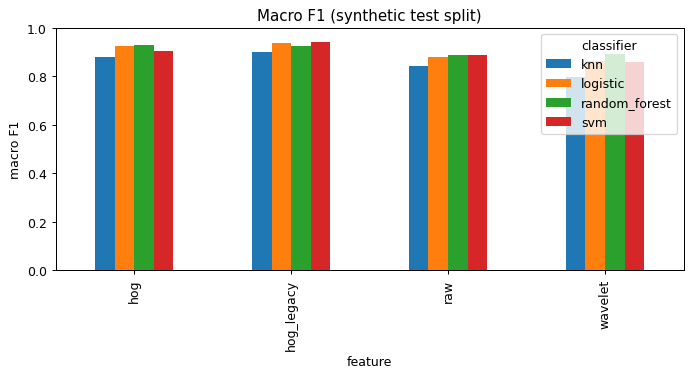

In [4]:
results.pivot(index='feature', columns='classifier', values='macro_f1').plot.bar(figsize=(9, 3.5), ylim=(0, 1), title='Macro F1 (synthetic test split)')
plt.ylabel('macro F1'); plt.show()

## 3. Cross-validation of the top configurations

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
cv_rows = []
for _, r in results.head(3).iterrows():
    fn = FEATURE_EXTRACTORS[r.feature]
    pipe = make_pipeline(StandardScaler(), build_classifier(r.classifier, 42))
    scores = cross_val_score(pipe, fn(list(X)), y, cv=5, scoring='f1_macro')
    cv_rows.append(dict(feature=r.feature, classifier=r.classifier,
                        cv_mean=scores.mean(), cv_std=scores.std()))
pd.DataFrame(cv_rows).round(4)

/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,feature,classifier,cv_mean,cv_std
0,hog_legacy,svm,0.9360,0.0573
1,hog_legacy,logistic,0.9341,0.0554
2,hog,random_forest,0.9231,0.0687


## 4. End-to-end benchmark (synthetic plates)
Character accuracy alone can mislead; the full pipeline includes segmentation and format correction.

In [6]:
import tempfile
from src.classifier import save_models
from src.pipeline import LPRPipeline
from scripts.generate_synthetic_plates import generate
from scripts.evaluate_lpr_end_to_end import levenshtein
bench = pd.read_csv(generate(Path(tempfile.mkdtemp()), n=30, seed=2026,
                             scene_fraction=0.3))
images = [cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB) for p in bench.image]
e2e = []
for feat in ['hog_legacy', 'hog']:
    clf, scaler = cache[(feat, 'svm')]
    d = Path(tempfile.mkdtemp()); save_models(clf, scaler, d, feature_method=feat)
    p = LPRPipeline(models_dir=str(d))
    exact = edits = total = 0
    for img, (_, row) in zip(images, bench.iterrows()):
        out = p.recognize(img, assume_plate_crop=bool(row.plate_crop),
                          verbose=False).get('plate_string', '')
        exact += out == row.label; edits += levenshtein(row.label, out)
        total += max(len(row.label), len(out), 1)
    e2e.append(dict(feature=feat, classifier='svm',
                    exact_plate_acc=exact / len(bench), char_acc=1 - edits / total))
pd.DataFrame(e2e).round(4)

✅ Đã lưu models tại /tmp/tmpk7497buw
Loaded OCR model from /tmp/tmpk7497buw (hog_legacy + svm)


✅ Đã lưu models tại /tmp/tmpb0lqp83m
Loaded OCR model from /tmp/tmpb0lqp83m (hog + svm)


,feature,classifier,exact_plate_acc,char_acc
0,hog_legacy,svm,0.7333,0.9283
1,hog,svm,0.7667,0.9084


## Conclusions (from the outputs above)
- **HOG features beat raw pixels and wavelets** for almost every classifier.
- Best character-level result: **HOG-324 + SVM** (94.1% accuracy, 5-fold CV macro-F1 93.6% ± 5.7%).
- HOG-1764 + SVM with the *untuned* default C=10 is weaker (89.6%); hyperparameters matter. `train_with_mlflow.py --tune` selects C=5, gamma=auto and reaches 92.9% on the full training set.
- End-to-end, HOG-1764 reads more **whole plates** correctly (76.7% vs 73.3% here; 85.0% vs 81.7% for the full production models on 60 plates) while HOG-324 has higher per-character accuracy. Full-plate accuracy is the business metric, so HOG-1764 is deployed.
- Logistic regression is 100x+ slower to train than SVM for similar accuracy.
- Caveats: 30 plates is a small benchmark (a few % is within noise) and all data is synthetic, so these numbers are an upper bound for real images.